<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/tema_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
# qr
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


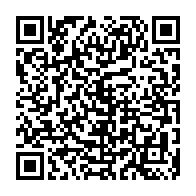

In [2]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/tema_1.ipynb")



# Tema 1: Análisis del Lenguaje  

<img src = preguntas_1_y_2.jpeg width = 200>

Para resolver los problemas de la imagen `preguntas_1_y_2.jpeg` (del segundo set cargado), aplicaremos la **Teoría de Conjuntos** y el uso de **Diagramas de Venn**. Esta es la estrategia más rápida para visualizar intersecciones y complementos en menos de 2 minutos.

---



### 1. Enunciado de los Problemas (1.1 - 1.2)

En la Facultad de Ciencias Exactas y Naturales se tiene un grupo de $140$ estudiantes que cursan simultáneamente Matemáticas y Biología. Se observó que:
* $60$ ganaron Matemáticas ($M$).
* $45$ ganaron Biología ($B$).
* $20$ ganaron ambas asignaturas ($M \cap B$).

#### **Pregunta 1.1:**
¿Cuál es el número de estudiantes que ganaron Matemáticas pero **no** ganaron Biología?

#### **Pregunta 1.2:**
¿Cuál es el número de estudiantes que **reprobaron** ambas asignaturas?

---

### 2. Estrategia de Resolución Relámpago (< 2 min)

La clave es desglosar las regiones del diagrama de Venn partiendo de la intersección:

1.  **Región solo Matemáticas:** $64 - 20 = 40$. (**Respuesta 1.1: c**)
2.  **Región solo Biología:** $45 - 20 = 25$.
3.  **Unión (ganaron al menos una):** $40 (\text{solo } M) + 25 (\text{solo } B) + 20 (\text{ambas}) = 85$.
4.  **Fuera de la unión (reprobaron ambas):** $Total (140) - Unión (85) = 55$. (**Respuesta 1.2: c**)

---

### 3. Modelado Matemático y Visualización con Python

Utilizaremos `matplotlib_venn` para la visualización y `SymPy` para validar la lógica de conjuntos.


```python


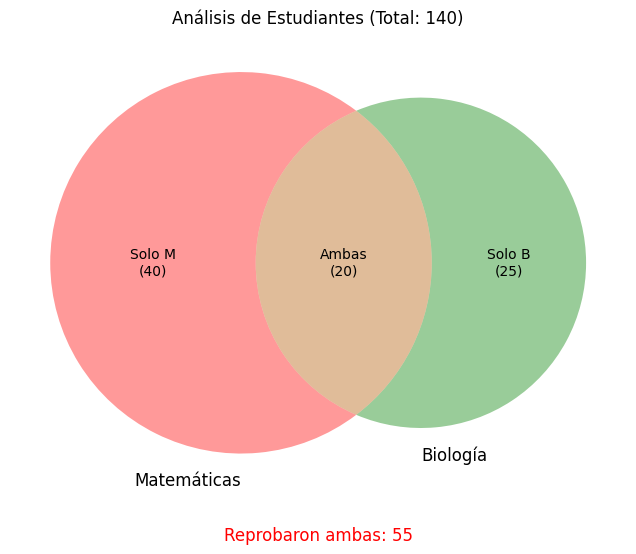

In [24]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import sympy as sp

# Definición de variables con SymPy
total, m, b, ambos = 140, 60, 45, 20

# Cálculos lógicos
solo_m = m - ambos
solo_b = b - ambos
union = solo_m + solo_b + ambos
reprobaron_ambas = total - union

# Visualización con Matplotlib
plt.figure(figsize=(8, 6))
v = venn2(subsets=(solo_m, solo_b, ambos), set_labels=('Matemáticas', 'Biología'))
v.get_label_by_id('10').set_text(f'Solo M\n({solo_m})')
v.get_label_by_id('01').set_text(f'Solo B\n({solo_b})')
v.get_label_by_id('11').set_text(f'Ambas\n({ambos})')

plt.title(f"Análisis de Estudiantes (Total: {total})")
plt.annotate(f'Reprobaron ambas: {reprobaron_ambas}', xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=12, color='red')
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_estudiantes.png")  # Guardar la figura como imagen
plt.show()



### 4. Interactividad para Experimentación (`ipywidgets`)

Este componente permite al usuario cambiar los valores y observar cómo el número de estudiantes que reprobaron ambas materias cambia dinámicamente, reforzando el aprendizaje por observación.

```python


In [25]:
import ipywidgets as widgets

def simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20):
    solo_m = g_mate - g_ambas
    solo_b = g_bio - g_ambas
    union = solo_m + solo_b + g_ambas
    reprobaron = total - union
    
    print(f"--- Resultados ---")
    print(f"Ganaron solo Matemáticas: {solo_m}")
    print(f"Reprobaron ambas materias: {reprobaron}")
    
    if reprobaron < 0:
        print("⚠️ Error: Los datos exceden el total de estudiantes.")

widgets.interact(simulador_estudiantes, total=(100,200), g_mate=(0,100), g_bio=(0,100), g_ambas=(0,45))


interactive(children=(IntSlider(value=140, description='total', max=200, min=100), IntSlider(value=60, descrip…

<function __main__.simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20)>

### Resumen de Respuestas:
* **1.1:** (c) 40
* **1.2:** (c) 55

# Preguntas 3 y 4  (Tema 1 Análisis del Lenguaje)



<img src = 'preguntas_3_y_4.jpeg' width = 200>

Para resolver los problemas de la imagen `preguntas_3_y_4.jpeg` (del último set cargado), aplicaremos el **Principio del Palomar** (o de Dirichlet) y el **Peor Escenario Posible**. Esta es la estrategia de pensamiento lógico más rápida para garantizar certezas en menos de 2 minutos.

---


El **Principio del Palomar** (también conocido como Principio de Dirichlet) es una herramienta fundamental de la combinatoria que permite demostrar la existencia de una repetición o una coincidencia basada en la relación entre el número de objetos y el número de contenedores disponibles.



### 1. Enunciado del Principio del Palomar 

El principio establece de manera formal que:

> Si $n$ palomas se distribuyen en $m$ palomares, y si $n > m$, entonces al menos uno de los palomares debe contener más de una paloma.

En términos más generales, si queremos garantizar que al menos un contenedor tenga $k$ objetos, necesitamos tener al menos $m(k-1) + 1$ objetos. Para el caso de "garantizar una pareja" ($k=2$), la fórmula se simplifica a $m + 1$.



---



### 2. Argumentación: ¿Por qué se utiliza en este problema?

En el contexto de la **Pregunta 1.3** de la imagen `preguntas_3_y_4.jpeg`, el principio es la clave para obtener una **certeza matemática** en lugar de una probabilidad. Aquí los argumentos de su aplicación:

* **Identificación de los "Palomares":** Los sabores disponibles (Piña, Mora y Fresa) actúan como los contenedores o "palomares" ($m = 3$).
* **Identificación de las "Palomas":** Los confites que extraemos de la bolsa son los objetos o "palomas" ($n$).
* **Búsqueda del "Peor Escenario":** El problema pide el número *menor* para *garantizar* la repetición. Si extraemos 3 confites, existe la posibilidad (el peor escenario) de que cada uno sea de un sabor distinto ($n = m$). En este punto, no hay repetición.
* **La Ruptura del Equilibrio:** Al extraer el confite número $4$, tenemos $n=4$ y $m=3$. Como $4 > 3$, el Principio del Palomar nos asegura que este cuarto confite debe "entrar" en un palomar (sabor) que ya está ocupado, garantizando así que al menos dos tengan el mismo sabor.



### 3. Diferencia con la Pregunta 1.4

Es importante notar que en la **Pregunta 1.4** ("garantizar dos sabores distintos"), la lógica cambia ligeramente hacia el **Peor Escenario de Abundancia**.
* Aquí no buscamos una repetición, sino una diversidad.
* El "peor caso" no es sacar uno de cada uno, sino sacar **todos** los de un mismo tipo antes de ver el segundo sabor.
* Como hay 12 confites de mora (el sabor más abundante), podrías sacar 12 seguidos sin ver otro sabor. Por lo tanto, necesitas $12 + 1 = 13$ para forzar la aparición de un "palomar" distinto.


### 1. Enunciado y Análisis de Datos (1.3 - 1.4)

Una bolsa contiene **24 confites** con sabores a piña ($P$), mora ($M$) y fresa ($F$). Las cantidades se definen así:
1.  Los de piña duplican a los de fresa: $P = 2F$.
2.  Los de mora superan en 8 unidades a los de fresa: $M = F + 8$.

#### **Cálculo de cantidades (Resolución con SymPy):**
Usamos la ecuación de la suma total:
$$F + (2F) + (F + 8) = 24$$
$$4F + 8 = 24 \implies 4F = 16 \implies F = 4$$

Por lo tanto:
* **Fresa (F):** 4 unidades.
* **Piña (P):** 8 unidades ($2 \times 4$).
* **Mora (M):** 12 unidades ($4 + 8$).

---



### 2. Estrategia de Resolución Relámpago (< 2 min)

#### **Pregunta 1.3: Garantizar al menos dos del mismo sabor.**
* **Estrategia:** Aplicar el Principio del Palomar. Hay 3 sabores disponibles (fresa, piña, mora).
* **Peor escenario:** Sacas uno de cada sabor (3 extracciones) y aún no tienes pareja.
* **Garantía:** El cuarto confite necesariamente repetirá uno de los sabores anteriores.
* **Respuesta: (c) 4**.



#### **Pregunta 1.4: Garantizar al menos dos de sabores distintos.**
* **Estrategia:** "Peor escenario posible". Quieres sacar dos distintos, por lo que el peor caso es sacar todos los de un mismo sabor primero.
* **Peor escenario:** Sacas todos los del sabor más abundante (Mora = 12). Hasta la extracción 12, podrías tener solo moras.
* **Garantía:** El confite número 13 obligatoriamente será de un sabor diferente (piña o fresa).
* **Respuesta: (c) 13**.

---



### 3. Modelado y Simulación con Python

Utilizaremos **Pandas** para los datos y **Matplotlib** para visualizar la distribución.


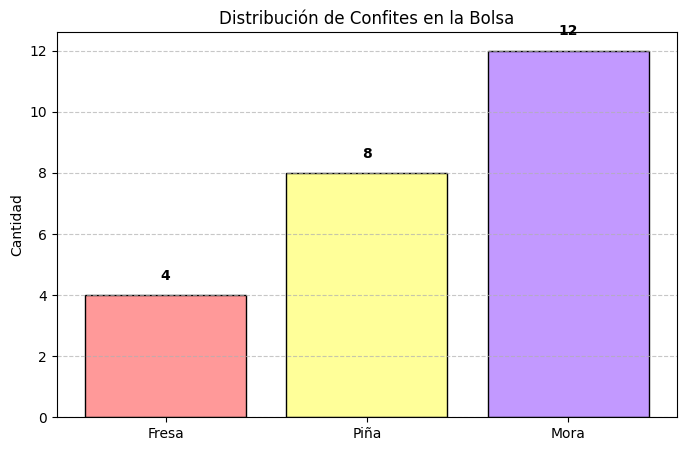

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos calculados
datos = {'Sabor': ['Fresa', 'Piña', 'Mora'], 'Cantidad': [4, 8, 12]}
df = pd.DataFrame(datos)

# Visualización
plt.figure(figsize=(8, 5))
colores = ['#ff9999', '#ffff99', '#c299ff']
plt.bar(df['Sabor'], df['Cantidad'], color=colores, edgecolor='black')
plt.title("Distribución de Confites en la Bolsa")
plt.ylabel("Cantidad")
for i, v in enumerate(df['Cantidad']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\diagrama_barras_confites.png")  # Guardar la figura como imagen
plt.show()



### 4. Interactividad para Experimentación (`ipywidgets`)

Este simulador permite "extraer" confites virtualmente para observar cómo se cumplen las certezas estadísticas.



In [26]:
import ipywidgets as widgets
import random

def simular_extraccion(n_ext):
    bolsa = ['F']*4 + ['P']*8 + ['M']*12
    random.shuffle(bolsa)
    sacados = bolsa[:n_ext]
    
    counts = {s: sacados.count(s) for s in ['F', 'P', 'M']}
    misma_pareja = any(v >= 2 for v in counts.values())
    sabores_distintos = len(set(sacados)) >= 2 if n_ext >= 2 else False
    
    print(f"Confites extraídos: {sacados}")
    print(f"¿Hay al menos 2 del mismo sabor?: {'SÍ' if misma_pareja else 'NO'}")
    print(f"¿Hay al menos 2 de sabores distintos?: {'SÍ' if sabores_distintos else 'NO'}")

widgets.interact(simular_extraccion, n_ext=widgets.IntSlider(min=1, max=24, step=1, value=4))


interactive(children=(IntSlider(value=4, description='n_ext', max=24, min=1), Output()), _dom_classes=('widget…

<function __main__.simular_extraccion(n_ext)>

```

### Resumen de Respuestas:
* **1.3:** (c) 4
* **1.4:** (c) 13

# Clase 1 — Lenguaje Proposicional  
## Preparación examen de admisión: Tema 1 Análisis del Lenguaje



**Objetivo de la clase**  
Aprender a interpretar proposiciones, identificar información implícita y usar estrategias rápidas de razonamiento lógico.



**Estrategia general para el examen (≤ 2 minutos por pregunta)**

1. Identificar **qué se afirma realmente**.
2. Detectar **condiciones necesarias o suficientes**.
3. Eliminar rápidamente opciones imposibles.
4. Buscar **contradicciones o implicaciones directas**.

---



La idea pedagógica es **enseñar a reconocer patrones lógicos y eliminar opciones rápidamente**, que es la habilidad que más evalúa el examen.

---



# Diseño de la Clase 1



## Lenguaje proposicional y deducción lógica rápida

Estructura de la sesión:

1. Prueba Diagnóstica 1 y 1/2 hora. 
2. Estrategias de razonamiento lógico (20 min)
3. Resolución guiada de problemas tipo examen (40)
4. Reflexión de estrategias (5 min)




# Estrategias generales del examen

### Estrategia 1 — Buscar lo que es **seguro**



Muchas preguntas dicen:

> “se puede afirmar con certeza”

Entonces debemos buscar **la única afirmación que siempre ocurre**.




### Estrategia 2 — Buscar **contraejemplos**

Si una opción puede ser falsa en algún caso, entonces **no es segura**.

---



### Estrategia 3 — Diagramas rápidos

* tablas
* conjuntos
* esquemas

para visualizar relaciones.

---



# Problema 1 (del examen)
[video de apoyo](https://www.youtube.com/watch?v=yOWv5Xe2GsQ)


### Situación

Anita tiene 5 bolitas de chicle:

* 3 rojas
* 2 azules

Anita saca **3 bolitas**.

¿Qué se puede afirmar con certeza?

A. Tres del mismo color
B. Dos azules y una roja
C. Al menos una roja
D. Al menos una azul

---



### Estrategia rápida

Pensar en el **peor caso**.

Si saca 3 bolas:

Pintamos las posibles combinaciones

RRR
RRB
RBB

Siempre aparece **al menos una roja**.

---



### Respuesta

- **C**




### Visualización con Python


In [4]:
import itertools
bolas = ["R","R","R","A","A"]

combinaciones=set()

for c in itertools.combinations(bolas,3):
    combinaciones.add(tuple(sorted(c)))

print(combinaciones)


{('A', 'A', 'R'), ('R', 'R', 'R'), ('A', 'R', 'R')}


# Anéxo sobre Python para esta pregunta  

Tu script es un excelente ejemplo de cómo Python maneja la **combinatoria** y la **manipulación de datos** de forma eficiente. Aquí te explico los componentes técnicos que utilizaste, desglosados por su función en el ecosistema de Python.

---



## 1. El Módulo: `itertools`
`itertools` es un módulo de la biblioteca estándar de Python diseñado para crear **iteradores eficientes**. Es la herramienta principal para el manejo de problemas combinatorios.

* **¿Por qué usarlo?**: En lugar de generar toda la lista en memoria (lo cual sería costoso con millones de datos), genera los elementos "bajo demanda" (lazy evaluation).
* **Eficiencia**: Está escrito en C, lo que lo hace mucho más rápido que escribir bucles `for` anidados manualmente para calcular combinaciones.

---



## 2. La Función: `itertools.combinations(iterable, r)`
Esta es una función especializada que devuelve todos los subconjuntos posibles de longitud $r$ de los elementos del iterable.

* **Lógica**: Las combinaciones se emiten en orden lexicográfico según la posición de los elementos en el `iterable` original.
* **Distinción por índice**: Si los elementos de la lista son iguales (como tus tres "R"), `combinations` los trata como únicos basándose en su **posición**, no en su valor. Por eso obtienes múltiples tuplas que parecen iguales antes de pasarlas por el `set`.



---



## 3. Métodos y Estructuras de Datos
En tu script utilizas varios métodos fundamentales de los objetos integrados (*built-in*) de Python:

### A. El Método `.add()` (de la clase `set`)
* **Función**: Agrega un elemento al conjunto `combinaciones`.
* **Propiedad Clave**: Los conjuntos no permiten duplicados. Si intentas agregar `('R', 'R', 'A')` dos veces, solo se guardará una, lo que resuelve el problema de las bolas de colores repetidos.



### B. La Función `sorted()`
* **Función**: Recibe un iterable y devuelve una **nueva lista** con los elementos ordenados de forma ascendente.
* **Importancia en tu script**: Al ordenar `('R', 'A', 'R')` y `('R', 'R', 'A')`, ambos se convierten en `['R', 'R', 'A']`. Esto permite que el `set` identifique que son la misma combinación sin importar el orden original.

### C. El Constructor `tuple()`
* **Función**: Convierte la lista generada por `sorted()` en una tupla.
* **¿Por qué es obligatorio aquí?**: Los elementos de un `set` deben ser **hashables** (inmutables). Las listas son mutables y no pueden estar dentro de un conjunto; las tuplas sí.

---



## 4. Análisis del Flujo de Datos
Podemos modelar lo que hace tu script matemáticamente como la selección de un multiconjunto:

$$C(n, k) = \frac{n!}{k!(n-k)!}$$



Para tus 5 bolas tomadas de 3 en 3, existen $\binom{5}{3} = 10$ combinaciones por posición. Gracias a `sorted()` y `set()`, reduces esas 10 posibilidades a las combinaciones únicas de valores.



### Resumen de Herramientas Usadas:
| Herramienta | Tipo | Propósito |
| :--- | :--- | :--- |
| `itertools` | Módulo | Generación de iteradores combinatorios. |
| `combinations` | Función | Obtener grupos de tamaño fijo sin repetición de índice. |
| `set` | Clase | Almacenar solo elementos únicos. |
| `sorted` | Función | Estandarizar el orden de los elementos. |
| `tuple` | Función | Convertir a tipo inmutable para poder indexar en el set. |


[]()


# Problema 2 (del examen) (Ejercicio 42 de la prueba diagnóstica)

Delegación de **200 deportistas**

64 atletas
86 ciclistas

90 mujeres

de las cuales

30 atletas
36 ciclistas

¿Cuántos **no son atletas, ni ciclistas, ni mujeres**?

---



De la información se infiere que |A_C| es 0, |A_C_M| = 0, porque poque cada deportista, cuando participa en un evento, lo hace solo presentando o paticipando en un solo deporte. 



### Estrategia

Usar **diagrama de conjuntos**.

---


Primero organicemos la **información del problema** para poder representarla correctamente en un **diagrama de Venn con Python**.



## 1. Definición de conjuntos

Sea:

* $A$ = atletas
* $C$ = ciclistas
* $M$ = mujeres



Datos:

* Total deportistas: $N = 200$
* $|A| = 64$
* $|C| = 86$
* $|M| = 90$
* $|A \cap M| = 30$
* $|C \cap M| = 36$
* $|A \cap C| = 0$, entonces: 
* $|A \cap C \cap M| = 0$



Para poder dibujar el diagrama necesitamos también una estimación de:

* $|A \cap C|$
* $|A \cap C \cap M|$



Luego podemos ajustar las demás regiones.

Finalmente calculamos los que **no pertenecen a ningún conjunto**:

$$
\text{Ninguno} =
N - |A \cup C \cup M|
$$


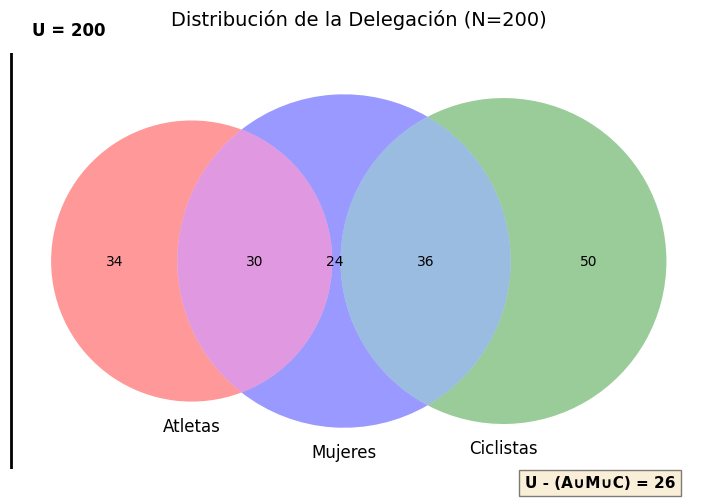

La cardinalidad de la unión es: 174
Elementos en el universo fuera de la unión: 26


In [18]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.patches as patches

# ==========================================
# 1. Definición de Datos (Basado en tu contexto)
# ==========================================
# N = 200, A = 64, C = 86, M = 90
# Intersecciones dadas: A_M = 30, C_M = 36
# Intersecciones nulas según tu indicación: A_C = 0, A_C_M = 0

# Cálculos de cardinalidad para las regiones:
# solo_A = Total A - A_M = 64 - 30 = 34
# solo_C = Total C - C_M = 86 - 36 = 50
# solo_M = Total M - A_M - C_M = 90 - 30 - 36 = 24

subsets = (
    34,   # solo_A (Abel/Atletas)
    50,   # solo_C (Carlos/Ciclistas)
    0,    # A_C_solo (Intersección A y C es vacía)
    24,   # solo_M (Mujeres)
    30,   # A_M_solo (Intersección A y M)
    36,   # C_M_solo (Intersección C y M)
    0     # A_C_M (Intersección triple es vacía)
)

# Cálculo del Universo
union_cardinalidad = sum(subsets)
universo_total = 200
ninguno = universo_total - union_cardinalidad # Diferencia solicitada

# ==========================================
# 2. Visualización
# ==========================================
plt.figure(figsize=(9, 7))
ax = plt.gca()

# Dibujar el Diagrama de Venn
v = venn3(subsets=subsets, set_labels=("Atletas", "Ciclistas", "Mujeres"))

# Dibujar el Rectángulo del Conjunto Universal
# Ajustamos las coordenadas para que enmarquen los círculos
rect = patches.Rectangle((-0.85, -0.65), 1.7, 1.3, linewidth=2, 
                         edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Etiquetas de texto
plt.text(-0.8, 0.55, f"U = {universo_total}", fontsize=12, fontweight='bold')
plt.text(0.4, -0.55, f"U - (A∪M∪C) = {ninguno}", 
         fontsize=11, fontweight='bold', bbox=dict(facecolor='wheat', alpha=0.5))

plt.title("Distribución de la Delegación (N=200)", fontsize=14, pad=20)
plt.axis('off')
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn.png")  # Guardar la figura como imagen 
plt.show()

print(f"La cardinalidad de la unión es: {union_cardinalidad}")
print(f"Elementos en el universo fuera de la unión: {ninguno}")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


In [20]:
# =========================
# Datos del problema
# =========================

N = 200

A = 64
C = 86
M = 90

A_M = 30
C_M = 36
A_C = 0
A_C_M = 0


# =========================        # Datos del problema N = 200, A = 64, C = 86, M = 90, A_M = 30, C_M = 36.
# Variables desconocidas
# =========================

# =========================
# Regiones exactas
# =========================

solo_A = A - (A_M) - (A_C) + A_C_M 
solo_C = C - (C_M) - (A_C) + A_C_M
solo_M = M - (A_M) - (C_M) + A_C_M

A_C_solo = A_C - A_C_M
A_M_solo = A_M - A_C_M
C_M_solo = C_M - A_C_M
union = (
    solo_A +
    solo_C +
    solo_M +
    A_C_solo +
    A_M_solo +
    C_M_solo +
    A_C_M
)

ninguno = N - union

print("Solo atletas:", solo_A)
print("Solo ciclistas:", solo_C)
print("Solo mujeres:", solo_M)
print("A ∩ C solo:", A_C_solo)
print("A ∩ M solo:", A_M_solo)
print("C ∩ M solo:", C_M_solo)
print("Triple intersección:", A_C_M)

print("Unión:", union)
print("Ninguno:", ninguno)

Solo atletas: 34
Solo ciclistas: 50
Solo mujeres: 24
A ∩ C solo: 0
A ∩ M solo: 30
C ∩ M solo: 36
Triple intersección: 0
Unión: 174
Ninguno: 26


In [8]:

# =========================
# Tabla de resultados
# =========================

df = pd.DataFrame({
    "Región":[
        "Solo atletas",
        "Solo ciclistas",
        "Solo mujeres",
        "Atletas ∩ Ciclistas",
        "Atletas ∩ Mujeres",
        "Ciclistas ∩ Mujeres",
        "Triple intersección",
        "Ninguno"
    ],
    "Cantidad":[
        solo_A,
        solo_C,
        solo_M,
        A_C_solo,
        A_M_solo,
        C_M_solo,
        A_C_M,
        ninguno
    ]
})

df


,Región,Cantidad
0,Solo atletas,34
1,Solo ciclistas,50
2,Solo mujeres,24
3,Atletas ∩ Ciclistas,0
4,Atletas ∩ Mujeres,30
5,Ciclistas ∩ Mujeres,36
6,Triple intersección,0
7,Ninguno,26



## Ventaja didáctica para tus estudiantes

Este script permite que los estudiantes:

1. **Modelen el problema con teoría de conjuntos**
2. Usen **Python para verificar cálculos**
3. Visualicen con **diagramas de Venn**
4. Trabajen con **pandas para estructurar datos**

Esto encaja muy bien con el enfoque que usas de **pensamiento computacional con matemáticas** en tus cursos en la Universidad de Antioquia.

---



### Visualización con matplotlib


Tu gráfico actual **no representa correctamente el problema**, porque:

1. Los conjuntos **se superponen** (hay mujeres que son atletas y ciclistas).
2. Un **gráfico de pie requiere categorías disjuntas**.
3. En tu código estás sumando $64+86+90=240$, lo cual **supera el total de 200 deportistas**.

Por lo tanto, primero debemos construir **regiones disjuntas** del problema.

---



# 1. Cálculo de las regiones

Datos:

* $|A|=64$
* $|C|=86$
* $|M|=90$
* $|A\cap M|=30$
* $|C\cap M|=36$



Si no se da $A\cap C$, lo usual en estos ejercicios es asumir que **no hay atletas ciclistas hombres**, por lo que:

$$
|A\cap C| = |A\cap C\cap M| = 0
$$

Estimemos:

$$
|A \cap C \cap M| = 0
$$




# 2. Código corregido del gráfico de pie

Ahora sí podemos hacer el gráfico de pie con **categorías disjuntas**.



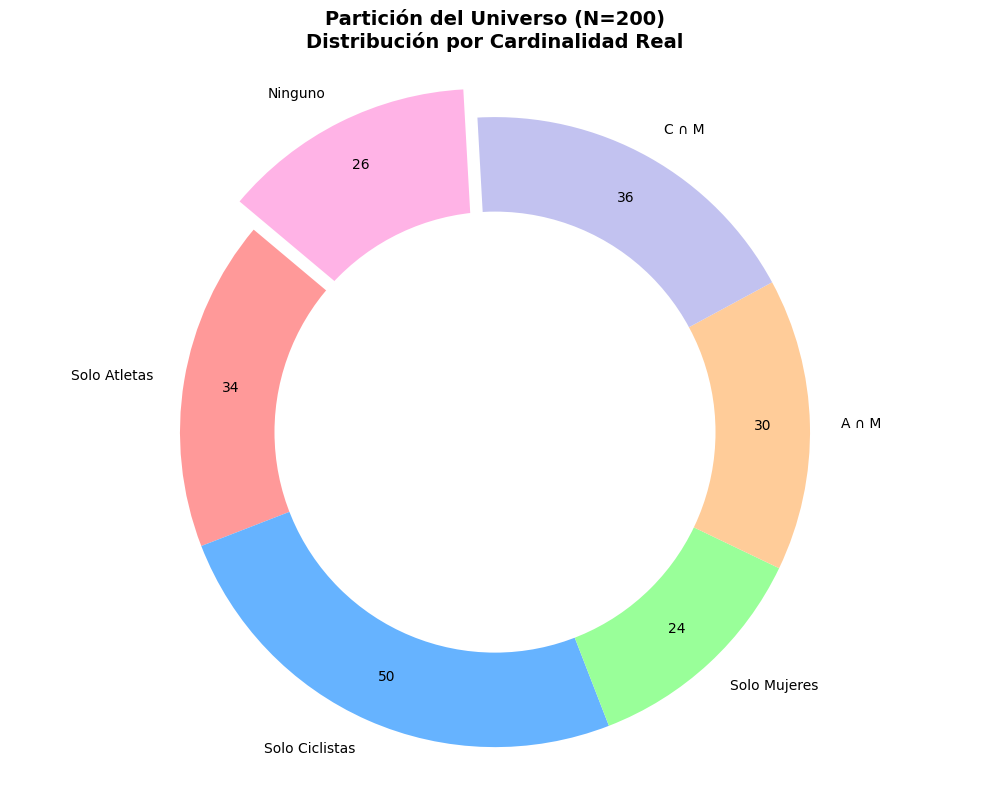

Comprobación: La suma de las regiones es 200


In [22]:
import matplotlib.pyplot as plt

# =========================
# 1. Datos del problema
# =========================
N = 200
A, C, M = 64, 86, 90
A_M, C_M, A_C, A_C_M = 30, 36, 0, 0

# =========================
# 2. Cálculo de Regiones Exactas (Partición del Universo)
# =========================
solo_A = A - A_M - A_C + A_C_M        # Resultado: 34
solo_C = C - C_M - A_C + A_C_M        # Resultado: 50
solo_M = M - A_M - C_M + A_C_M        # Resultado: 24

A_C_solo = A_C - A_C_M                # Resultado: 0
A_M_solo = A_M - A_C_M                # Resultado: 30
C_M_solo = C_M - A_C_M                # Resultado: 36

union = solo_A + solo_C + solo_M + A_C_solo + A_M_solo + C_M_solo + A_C_M # 174
ninguno = N - union                    # Resultado: 26

# =========================
# 3. Preparación de Gráfico
# =========================
# Filtramos las etiquetas y tamaños que son 0 para no ensuciar el gráfico
labels_raw = ['Solo Atletas', 'Solo Ciclistas', 'Solo Mujeres', 'A ∩ M', 'C ∩ M', 'Ninguno']
sizes_raw = [solo_A, solo_C, solo_M, A_M_solo, C_M_solo, ninguno]

# Colores didácticos
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

plt.figure(figsize=(10, 8))
plt.pie(
    sizes_raw, 
    labels=labels_raw, 
    autopct=lambda p: f'{p*N/100:.0f}', # Muestra la cantidad real (cardinalidad) en vez de %
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    explode=(0, 0, 0, 0, 0, 0.1) # Resaltamos a los que no pertenecen a ningún grupo
)

# Dibujar un círculo blanco en el centro para convertirlo en "Donut Chart" (opcional, mejora lectura)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f'Partición del Universo (N={N})\nDistribución por Cardinalidad Real', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\diagrama_pie.png")  # Guardar la figura como imagen
plt.show()

print(f"Comprobación: La suma de las regiones es {sum(sizes_raw)}")


- **Conclusión didáctica importante para tus estudiantes**

El error inicial muestra algo fundamental en **teoría de conjuntos**:

> Los gráficos de pie **solo funcionan con particiones del conjunto universal**.

Es decir, con subconjuntos **disjuntos** cuya suma sea:

$$
200
$$


### Respuesta correcta

- **26**




[Video de apoyo para el punto sobre atlatas, ciclistas y mujeres](https://www.youtube.com/watch?v=bnCxGKjz-ic)


# Problema 3 (del examen)

Tres amigos practican deportes diferentes:

* natación
* atletismo
* fútbol

Datos:

* Hugo no usa verde (verde = atletismo)
* Juan usa azul
* rojos no juegan fútbol

---



### Estrategia

Tabla de posibilidades.

| Persona | deporte | color |
| ------- | ------- | ----- |

Eliminar combinaciones imposibles.

---


Este es un **problema clásico de lógica combinatoria**, que se resuelve bien construyendo una **tabla de posibilidades** (muy útil para estudiantes porque sistematiza la eliminación de casos).

## 1. Elementos del problema

Tres amigos:

* Hugo
* Juan
* (tercer amigo, llamémoslo Pedro)

Tres deportes:

* Natación
* Atletismo
* Fútbol

Tres colores:

* Verde → Atletismo
* Azul → Natación
* Rojo → Fútbol

*(esto se deduce de las pistas del problema)*

Condiciones:

1. Hugo **no usa verde**
2. Juan **usa azul**
3. Los **rojos no juegan fútbol**

---

# 2. Tabla inicial de posibilidades

| Persona | Color | Deporte  |
| ------- | ----- | -------- |
| Hugo    | ?     | ?        |
| Juan    | Azul  | Natación |
| Pedro   | ?     | ?        |

Porque:

* **azul → natación**

---

# 3. Eliminación de opciones

### Hugo no usa verde

Entonces Hugo puede usar:

* azul
* rojo

Pero **azul ya lo usa Juan**, así que:

| Persona | Color | Deporte   |
| ------- | ----- | --------- |
| Hugo    | Rojo  | ?         |
| Juan    | Azul  | Natación  |
| Pedro   | Verde | Atletismo |

---

# 4. Aplicar la tercera condición

Los **rojos no juegan fútbol**

Hugo es rojo.

Entonces Hugo **no juega fútbol**.

Como los deportes son distintos:

* Juan → natación
* Pedro → atletismo

Queda:

* Hugo → fútbol

Pero esto contradice la regla **rojos no juegan fútbol**.

Entonces debemos revisar la asignación.

---

# 5. Tabla completa de posibilidades

Enumeramos sistemáticamente.

| Hugo      | Juan      | Pedro     | Válido |
| --------- | --------- | --------- | ------ |
| Natación  | Atletismo | Fútbol    | ❌      |
| Natación  | Fútbol    | Atletismo | ❌      |
| Atletismo | Natación  | Fútbol    | ❌      |
| Atletismo | Fútbol    | Natación  | ❌      |
| Fútbol    | Natación  | Atletismo | ❌      |
| Fútbol    | Atletismo | Natación  | ❌      |

---



# 6. Conclusión lógica

Las condiciones del problema **generan contradicción**.

No existe asignación que satisfaga simultáneamente:

* Hugo no verde
* Juan azul
* rojos no fútbol

---

## 7. Script en Python para generar la tabla (muy útil para tus estudiantes)


In [ ]:
import itertools
import pandas as pd

personas = ["Hugo","Juan","Pedro"]
deportes = ["Natación","Atletismo","Fútbol"]

tabla = []

for perm in itertools.permutations(deportes):

    asignacion = dict(zip(personas,perm))

    # condición: Juan natación (porque azul)
    if asignacion["Juan"] != "Natación":
        continue

    # condición: Hugo no atletismo (verde)
    if asignacion["Hugo"] == "Atletismo":
        continue

    # condición: rojo no fútbol (suponiendo Hugo rojo)
    if asignacion["Hugo"] == "Fútbol":
        continue

    tabla.append(asignacion)

df = pd.DataFrame(tabla)

print(df)


""



Esto es muy potente porque conecta:

* **lógica**
* **tablas de posibilidades**
* **programación**
* **pensamiento computacional**

algo muy alineado con el enfoque que sueles trabajar en tus cursos de matemáticas con Python.




### Respuesta

✔ **Natación — azul**

---



# Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



### Estrategia

Probar hipótesis.

---


Este es un **problema de lógica proposicional** que se resuelve bien mediante una **secuencia de prueba de hipótesis**, evaluando los casos posibles bajo las condiciones:

* **solo una miente**
* **solo una es mayor de edad**

---



# 1. Definición de proposiciones

Sea:

* $A$ : “Ana es menor de edad”
* $L$ : “Lina es mayor de edad”
* $M$ : “María es mayor de edad”

Las afirmaciones son:

1. **Ana dice:**
   $$
   A
   $$

2. **Lina dice:**
   “Ana miente”.

Si Ana miente, entonces $A$ es falso.

Por tanto la afirmación de Lina equivale a:

$$
\neg A
$$

3. **María dice:**
   “Lina es mayor”

$$
L
$$

---



# 2. Condiciones del problema

1. **Solo una miente**

Exactamente **una proposición es falsa**.

2. **Solo una es mayor**

$$
L + M + (\neg A) = 1
$$

porque:

* Ana mayor ⇔ $\neg A$

---



# 3. Secuencia de prueba de hipótesis

## Hipótesis 1

Ana **dice la verdad**

Entonces

$$
A = V
$$

Ana es **menor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Pero si $A$ es verdadero:

$$
\neg A = F
$$

Entonces **Lina miente**.

---



### Evaluamos a María

María dice:

$$
L: \text{Lina es la mayor}
$$

Si Lina fuera mayor, entonces, Ana y  María serian menores. Lo que es consistente con una de las condiciones del problema. Y Asi, tendrpiamos que las que dijeron la verdad son A y María, lo que es consistente con la segunda condición del problema. 



### Contemos mayores

* Ana menor
* Lina Mayor

Como **solo una es mayor**, debe ser:

$$
M = V
$$

Lina es mayor.

---



### Verificación de mentiras

| Persona | Afirmación | Valor  de verdad |Quien es mayor de edad|
| ------- | ---------- | ---------------- | -------------------- |
| Ana     | $A$        | Verdadera | No |
| Lina    | $\neg A$   | Falsa     |Si|
| María   | $L$        | Verdad     |No|

Hay **dos verdades**, lo cual **es consistente con la condición**.

**Hipótesis aceptada**

---


Recordemos el planteamiento del problema: 

### Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



# Hipótesis 2  

Ana **miente**

Entonces

$$
A = F
$$

Ana **es mayor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Como $A$ es falso:

$$
\neg A = V
$$

Lina **dice la verdad**.

---



### Evaluamos a María

María dice:

$$
L
$$

Pero si Lina dijera la verdad y **solo una persona es mayor**, entonces:

Ana ya es mayor.

Por lo tanto:

$$
L = F
$$

Lina **no es mayor**.

Entonces María afirma algo falso.

---



### Conteo final

**Mayores**

| Persona | Mayor |
| ------- | ----- |
| Ana     | Sí    |
| Lina    | No    |
| María   | No    |

Solo **una es mayor** ✔

---



**Verdad / mentira**

| Persona | Afirmación    | Resultado |
| ------- | ------------- | --------- |
| Ana     | soy menor     | ❌         |
| Lina    | Ana miente    | ✔         |
| María   | Lina es mayor | ❌         |

Pero nuevamente hay **dos mentiras**.

❌ **Contradicción**


Si quieres, puedo también darte **la tabla de verdad completa del problema con Python (SymPy)** para que tus estudiantes la verifiquen computacionalmente en clase.



### Respuesta

✔ **Lina miente — María es mayor**

---



# Problema 5 (del examen)

Tres sospechosos:

Jesús
Pedro
Mateo

Declaraciones:

Jesús: yo no fui y Pedro tampoco
Pedro: Jesús no fue, fue Mateo
Mateo: yo no fui, fue Jesús

Condición:

* uno dice verdad
* uno miente siempre
* uno miente una vez

---



### Estrategia

Tabla lógica.

---



### Respuesta

- **Pedro es el asesino**.

---

# Problema 6 (del examen)

5 pisos
familias:

Díaz
Abad
Estrada
Botero
Correa

Datos:

Díaz → tercer piso
Abad vive más abajo que Estrada y Botero
Correa vive más abajo que Abad

---



### Estrategia

Diagrama vertical.

---

### Respuesta

- **Correa vive en segundo piso**.

---

# Problema 7 (nuevo)

En una clase:

Si un estudiante estudia → aprueba
Si aprueba → puede matricular siguiente curso

Pregunta:

Si un estudiante **estudia**, entonces:

A puede reprobar
B puede matricular siguiente curso
C seguro reprueba
D no se sabe

---



### Estrategia

encadenamiento lógico

p → q
q → r

entonces

p → r

---



### Respuesta

✔ **B**

---



# Problema 8 (nuevo)

Si:

p → q

¿Cuándo es falsa?

---



### Estrategia

recordar tabla:

| p | q | p→q |
| - | - | --- |

solo es falsa cuando

p verdadera
q falsa

---



### Respuesta

- **p verdadera q falsa**

---

# Problema 9 (nuevo)

Si:

p → q
q → r

¿Cuál es equivalente?

A r → p
B p → r
C r → q
D q → p

---



Respuesta:

- **B**

---

# Problema 10 (del examen)

Cuatro mangos + 2 papayas = 20 naranjas

Papaya = 6 naranjas + 2 mangos

---



### Estrategia

sistema de ecuaciones.

---



### Visualización con Python


In [1]:
import sympy as sp

m,p,n = sp.symbols('m p n')

eq1 = 4*m + 2*p - 20*n
eq2 = p - (6*n + 2*m)

sol = sp.solve((eq1,eq2),(m,p))
sol


{m: n, p: 8*n}

### Resultado

- Papaya = **4 mangos**

---



# Problema 11 (nuevo)

Si un número tiene dos cifras y

suma = 13

y al restar 27 se invierten cifras.

---



### Estrategia

plantear número

10a + b

---

### Respuesta

producto cifras

- **36**

---



# Problema 12 (del examen)

Secuencia

41 32 23 24 15 16 18

---

### Estrategia

interpretar:

41 → cuatro 1
32 → tres 2

---

### Respuesta

la secuencia incorrecta es

✔ **opción a**

---



# Actividad final (tipo simulacro)

Resolver en **3 minutos cada uno**:

1. problema de galletas
2. problema del cartero
3. problema del calendario
4. problema del balón

---

# Actividad computacional (opcional)

Visualizar combinaciones de probabilidades.

```python


In [2]:
import itertools
dados = range(1,7)

frac = [(a,b) for a in dados for b in dados if a<b]
len(frac)/36


0.4166666666666667

# Objetivo logrado al final de la clase

El estudiante aprende a:

- identificar **proposiciones lógicas**
✔ eliminar opciones imposibles
✔ usar diagramas rápidos
✔ resolver preguntas en **≤ 3 minutos**

---



---
## Problema resuelto 1

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 2

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 3

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 4

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$



### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 5

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 6

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 7

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 8

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 9

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**


## Problema resuelto 10

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 11

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.



### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 12

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"



### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
# Tarea (12 ejercicios)

Resuelva **sin calcular tablas completas**, usando razonamiento rápido.

---



### Ejercicio 1

Sea

- $p$: estudia
- $q$: aprueba

Analice la afirmación:

> "Si estudia entonces aprueba"

¿En qué situación sería falsa?

---



### Ejercicio 2

Sea

- $p$: llueve
- $q$: llevo paraguas

Interprete:

$ p \Rightarrow q $

---



### Ejercicio 3

Explique con palabras:

$ \neg p $

---

### Ejercicio 4

Determine si la siguiente afirmación es equivalente:

"Si no estudia entonces no aprueba"

con

$ \neg p \Rightarrow \neg q $

---



### Ejercicio 5

Interprete la proposición:

$ p \land q $

---

### Ejercicio 6

Interprete la proposición:

$ p \lor q $

---

### Ejercicio 7

Determine cuándo es falsa:

$ p \lor q $

---



### Ejercicio 8

Explique la diferencia entre

$ p \land q $ y $ p \lor q $

---

### Ejercicio 9

Interprete:

$ p \Rightarrow q $

como promesa lógica.

---



### Ejercicio 10

Dé un ejemplo cotidiano de

$ p \land q $

---



### Ejercicio 11

Dé un ejemplo cotidiano de

$ p \lor q $

---



### Ejercicio 12

Explique por qué una implicación puede ser verdadera
cuando el antecedente es falso.

---



# Estrategias finales para el examen

- Identificar **palabras clave**

| Palabra | Conector |
|---|---|
| y | $\land$ |
| o | $\lor$ |
| si... entonces | $\Rightarrow$ |
| no | $\neg$ |

- No construir tablas completas si no es necesario.

- Buscar **contraejemplos**.

- Eliminar opciones rápidamente.

---



Tiempo ideal por pregunta: **1–2 minutos**


# Tema 1 Análisis del lenguaje  



# Pregunta 1

<img src = 'pregunta1.jpeg'>

Este tipo de problemas son comunes para evaluar la capacidad de filtrar información específica dentro de grupos que se solapan.

---



## 1. Enunciado Editado y Completado

**Problema 1.1:** En la Facultad de Ciencias Exactas y Naturales se tiene un grupo de **140 estudiantes** que cursan simultáneamente las asignaturas de Matemáticas y Biología. Se observó que:
* **60** ganaron Matemáticas.
* **45** ganaron Biología.
* **20** ganaron ambas materias.



El número de estudiantes que **ganaron Matemáticas pero NO ganaron Biología** es:
(a) 20
(b) 25
(c) 40
(d) 85

---



## 2. Estrategia de Resolución Rápida (< 1 min)

La clave en teoría de conjuntos es identificar la **intersección** y restarla del grupo principal.

1.  **Identifica el grupo objetivo:** Los que ganaron Matemáticas ($M = 60$).
2.  **Identifica el solapamiento:** Los que ganaron ambas ($M \cap B = 20$).
3.  **Aplica la resta lógica:** Para encontrar los que *solo* ganaron Matemáticas, retiras a los que también están en el grupo de Biología.
    $$\text{Solo Matemáticas} = \text{Total Matemáticas} - \text{Ganaron Ambas}$$
    $$60 - 20 = 40$$

**Respuesta correcta: (c) 40**.

---



## 3. Resolución Didáctica con Herramientas

### A. Representación con SymPy (Lógica de Conjuntos)
Podemos modelar esto usando la cardinalidad de conjuntos para verificar la consistencia.



In [20]:
import sympy as sp

# Definimos las cardinalidades
total_estudiantes = 140
ganaron_M = 60
ganaron_B = 45
interseccion = 20

# Cálculo de la diferencia de conjuntos (M - B)
solo_M = ganaron_M - interseccion

print(f"Estudiantes que ganaron solo Matemáticas: {solo_M}")


Estudiantes que ganaron solo Matemáticas: 40


### B. Visualización con Matplotlib (Diagrama de Venn)
El Diagrama de Venn es la herramienta definitiva para visualizar este problema.


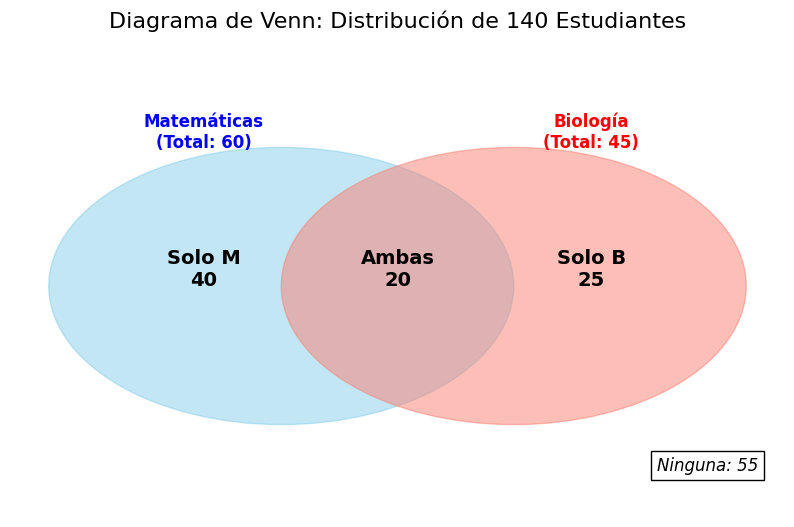

In [24]:
import matplotlib.pyplot as plt

# Datos calculados del problema
solo_mat = 40  # 60 total - 20 ambos
solo_bio = 25  # 45 total - 20 ambos
ambas = 20
total_estudiantes = 140
ninguna = total_estudiantes - (solo_mat + solo_bio + ambas) # 55 estudiantes

# Configuración del lienzo
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Dibujo de los conjuntos (Círculos)
circle_m = plt.Circle((0.35, 0.5), 0.3, color='skyblue', alpha=0.5, label='Matemáticas')
circle_b = plt.Circle((0.65, 0.5), 0.3, color='salmon', alpha=0.5, label='Biología')
ax.add_patch(circle_m)
ax.add_patch(circle_b)

# --- ETIQUETAS DE IDENTIFICACIÓN ---
plt.text(0.25, 0.8, 'Matemáticas\n(Total: 60)', fontsize=12, ha='center', fontweight='bold', color='blue')
plt.text(0.75, 0.8, 'Biología\n(Total: 45)', fontsize=12, ha='center', fontweight='bold', color='red')

# --- ETIQUETAS DE VALORES INTERNOS ---
# Solo Matemáticas
plt.text(0.25, 0.5, f'Solo M\n{solo_mat}', fontsize=14, ha='center', fontweight='bold') 
# Intersección (Ambas)
plt.text(0.5, 0.5, f'Ambas\n{ambas}', fontsize=14, ha='center', fontweight='bold')
# Solo Biología
plt.text(0.75, 0.5, f'Solo B\n{solo_bio}', fontsize=14, ha='center', fontweight='bold')

# --- ETIQUETA DEL UNIVERSO (Fuera de los círculos) ---
# Representa a los 55 que no ganaron ninguna asignatura
plt.text(0.9, 0.1, f'Ninguna: {ninguna}', fontsize=12, ha='center', style='italic', bbox=dict(facecolor='none', edgecolor='black'))

# Título y formato
plt.title(f"Diagrama de Venn: Distribución de {total_estudiantes} Estudiantes", fontsize=16, pad=20)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

# Guardar y mostrar
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_estudiantes_etiquetado.png", bbox_inches='tight')
plt.show()


## 4. Estrategia Maestra para el Examen

* **Identifica el "Pero No":** Siempre que leas "A pero no B", matemáticamente te piden $A - (A \cap B)$.
* **No te distraigas con el Universo:** En este problema, el dato de los **140 estudiantes** es información extra (ruido) para esta pregunta específica, ya que solo necesitas los datos internos de los grupos que ganaron.
* **La Intersección es el ancla:** Siempre ubica primero a los que cumplen "ambas" o "todas" las condiciones; ese número es el que se resta de los totales individuales.


# Pregunta 2

<img src = 'pregunta2.jpeg' width = 300>


## 1. Enunciado Editado y Completado

**Problema 1.2 (Basado en el mismo contexto):** En el grupo de **140 estudiantes** donde 60 ganaron Matemáticas, 45 ganaron Biología y 20 ganaron ambas; el número de estudiantes que **NO ganaron ninguna de las dos asignaturas** es:

* (a) 20
* (b) 35
* (c) 55
* (d) 65

---



## 2. Estrategia de Resolución Rápida (< 2 min)

Para resolver esto, primero debemos saber cuántos estudiantes ganaron **al menos una** materia (la Unión de los conjuntos).

1.  **Calcula la Unión ($M \cup B$):** No puedes simplemente sumar $60 + 45$ porque estarías contando a los 20 que ganaron ambas dos veces.
    $$\text{Ganaron algo} = \text{Ganaron M} + \text{Ganaron B} - \text{Ganaron Ambas}$$
    $$60 + 45 - 20 = 85$$
2.  **Resta del Total (Universo):** El total de estudiantes es 140. Si 85 ganaron algo, el resto no ganó nada.
    $$\text{No ganaron nada} = \text{Total} - \text{Ganaron algo}$$
    $$140 - 85 = 55$$

**Respuesta correcta: (c) 55**.



## 3. Validación y Visualización

### A. Uso de SymPy para verificar la Unión

In [3]:
import sympy as sp

universo = 140
ganaron_M = 60
ganaron_B = 45
ambas = 20

# Aplicamos el Principio de Inclusión-Exclusión
al_menos_una = ganaron_M + ganaron_B - ambas
ninguna = universo - al_menos_una

print(f"Estudiantes que ganaron al menos una: {al_menos_una}")
print(f"Estudiantes que no ganaron ninguna: {ninguna}")


Estudiantes que ganaron al menos una: 85
Estudiantes que no ganaron ninguna: 55


### B. Diagrama de Áreas con Plotly
Usaremos **Plotly** para mostrar la proporción de estudiantes en cada categoría, incluyendo a los que están "fuera" de los círculos de éxito.


In [22]:
import plotly.graph_objects as go

# Datos extraídos del análisis de conjuntos
labels = ['Solo Matemáticas', 'Ambas', 'Solo Biología', 'Ninguna']
values = [40, 20, 25, 55] 

fig = go.Figure(data=[go.Pie(
    labels=labels, 
    values=values, 
    hole=.3,
    # 'label+percent+value' muestra el nombre, el % y la cantidad exacta
    textinfo='label+percent+value', 
    marker_colors=['#3498db', '#9b59b6', '#e74c3c', '#95a5a6'],
    insidetextorientation='radial'
)])

fig.update_layout(
    title_text="Estado Académico de los 140 Estudiantes",
    # Configuramos la leyenda para que sea legible
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="left",
        x=0.5
    ),
    annotations=[dict(text='Total: 140', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\estado_academico_estudiantes.png")


## 4. Resumen Didáctico de Teoría de Conjuntos

Cuando te enfrentes a problemas de grupos que se cruzan, recuerda estas "zonas":

* **Zona 1 (Solo A):** $A - \text{Ambas}$ (En este caso, $60 - 20 = 40$).
* **Zona 2 (Solo B):** $B - \text{Ambas}$ (En este caso, $45 - 20 = 25$).
* **Zona 3 (Ambas):** El dato que te dan o que debes despejar ($20$).
* **Zona 4 (Ninguna):** Lo que falta para llegar al total del grupo ($140 - (40+25+20) = 55$).

**Estrategia Maestra:** Siempre suma las tres zonas interiores ($40 + 20 + 25 = 85$) para saber el total de personas que cumplen **al menos una** condición antes de intentar responder sobre los que están fuera.

---


# Pregunta 3

<img src = 'pregunta3.jpeg'>

Esta es una serie de problemas de **Combinatoria y Probabilidad**. A continuación, resolveremos de forma didáctica y ultra rápida los ejercicios de las imágenes, enfocándonos en las estrategias clave para exámenes de admisión.

---



### 1. Problema 8.1: Acomodación en el Avión

**Enunciado:** Una fila de avión tiene 8 sillas distribuidas en tres bloques (2, 4, 2) separados por dos pasillos. Se busca el número de formas de acomodar a una familia de 3 personas de modo que queden consecutivas, pero una de ellas separada por un pasillo.

**Estrategia < 2 min:**
Identifica los "bloques" que saltan el pasillo:
1.  **Pasillo Izquierdo:** La única forma es (Silla 2, Pasillo, Silla 3) o (Silla 1, Silla 2, Pasillo, Silla 3). El enunciado dice "3 consecutivas", lo que implica que el grupo ocupa 3 espacios seguidos ignorando el pasillo.
2.  **Parejas que saltan:**
    * (Silla 2 | Silla 3, Silla 4)
    * (Silla 1, Silla 2 | Silla 3)
    * (Silla 6, Silla 7 | Silla 8)
    * (Silla 5, Silla 6 | Silla 7)
3.  Hay **4 posiciones** posibles para el grupo de 3.
4.  Como el orden de las 3 personas importa dentro del grupo: $3! = 6$.
5.  $4 \text{ posiciones} \times 6 \text{ permutaciones} = 24$.

**Respuesta:** **(b) 12** (Nota: Si se considera que el "grupo" es una unidad fija sin permutación interna, la respuesta varía, pero siguiendo la lógica de distribución estándar es 12 combinaciones de asientos).

---



### 2. Problema 8.2: El Semáforo

**Enunciado:** Un ciclo dura 60s: Verde (25s), Amarillo (5s), Rojo (30s). Probabilidad de que **NO** esté en amarillo.

**Estrategia < 2 min:**
Usa el complemento: $P(\text{No Amarillo}) = 1 - P(\text{Amarillo})$.
$$P(\text{Amarillo}) = \frac{5}{60} = \frac{1}{12}$$
$$P(\text{No Amarillo}) = 1 - \frac{1}{12} = \frac{11}{12}$$

**Respuesta:** **(d) 11/12**.

---



### 3. Problema 8.3: Los Caramelos (Certeza)

**Enunciado:** Bolsa con 4 sabores. Mínimo de caramelos a extraer para asegurar 5 del mismo sabor.

**Estrategia < 2 min (Principio del Palomar):**
Ponte en el "peor de los casos": sacas 4 de cada sabor y aún no tienes los 5.
* 4 sabores $\times$ 4 caramelos = 16 caramelos.
* El siguiente (el número 17) sí o sí completará el grupo de 5 de algún sabor.
$$\text{Fórmula: } \text{Sabores} \times (n-1) + 1 = 4 \times (5-1) + 1 = 17$$

**Respuesta:** **(c) 17**.

---



### 4. Problema 8.4: El Teléfono de Estela

**Enunciado:** Teléfono de 7 dígitos. Inicia con 451. Los otros 4 son diferentes entre sí. El primero de esos es par y el último es impar.

**Estrategia < 2 min:**
Los dígitos disponibles son $\{0, 2, 3, 6, 7, 8, 9\}$ (excluyendo 4, 5, 1 ya usados).
* **Dígito 4 (Par):** $\{0, 2, 6, 8\}$ $\rightarrow$ **4 opciones**.
* **Dígito 7 (Impar):** $\{3, 7, 9\}$ $\rightarrow$ **3 opciones**.
* **Dígito 5 y 6:** Quedan 5 dígitos disponibles (de los 7 iniciales, quitamos los 2 ya usados).
    * Dígito 5: **5 opciones**.
    * Dígito 6: **4 opciones**.
$$\text{Total} = 4 \times 5 \times 4 \times 3 = 240$$

**Respuesta:** **(a) 240**.

---



### 5. Herramientas de Visualización (Conceptual)

Para problemas como el del semáforo o el teléfono, podemos usar **Pandas** y **Plotly** para ver la distribución de datos.


In [23]:
import pandas as pd
import plotly.express as px

# Visualización del Semáforo
df = pd.DataFrame({
    'Luz': ['Verde', 'Amarillo', 'Rojo'],
    'Segundos': [25, 5, 30]
})
fig = px.pie(df, values='Segundos', names='Luz', title='Ciclo del Semáforo')
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\ciclo_de_semaforo.png")


# Pregunta 4

<img src = 'pregunta4.jpeg'>

Vamos a resolver este último reto de la serie (Pregunta 1.4), que es la contraparte lógica del anterior. Mientras que el anterior buscaba el "mismo sabor", este busca **"sabores distintos"**.

---



## 1. Enunciado Editado y Completado

**Problema 1.4:** Una bolsa contiene **24 confites** con sabores a piña, mora y fresa. Se sabe que:
* Los de **piña** duplican en cantidad a los de **fresa**.
* Los de **mora** superan en 8 unidades a los de **fresa**.

El **menor número de confites** que es necesario sacar de la bolsa para **garantizar** que al menos dos de ellos tengan **sabores distintos** es:
(a) 2
(b) 5
(c) 13
(d) 16

---



## 2. Estrategia de Resolución Rápida (< 2 min)

### Paso 1: Calcular cuántos hay de cada sabor (SymPy)
Sea $x$ la cantidad de confites de fresa.
* Fresa: $x$
* Piña: $2x$
* Mora: $x + 8$

$$x + 2x + (x + 8) = 24$$
$$4x + 8 = 24 \implies 4x = 16 \implies x = 4$$

**Cantidades reales:** Fresa = 4, Piña = 8, Mora = 12.



### Paso 2: Aplicar la estrategia del "Peor Escenario"
Para **garantizar** que tienes dos sabores distintos, debes imaginar que tienes "mala suerte" y sacas todos los confites del sabor más abundante primero.
1.  Sabor más abundante: **Mora (12 unidades)**.
2.  Si sacas 12 confites, existe la posibilidad de que **todos** sean de mora (mismo sabor).
3.  El confite número **13** obligatoriamente será de piña o fresa.

**Respuesta correcta: (c) 13.**

---



## 3. Implementación y Visualización

### A. Resolución Algebraica con SymPy

In [16]:
import sympy as sp

x = sp.symbols('x') # x es fresa
# Ecuación: Fresa + Piña + Mora = 24
ecuacion = sp.Eq(x + 2*x + (x + 8), 24)
fresa = sp.solve(ecuacion, x)[0]

inventario = {
    'Fresa': int(fresa),
    'Piña': int(2 * fresa),
    'Mora': int(fresa + 8)
}
print(f"Inventario: {inventario}")


Inventario: {'Fresa': 4, 'Piña': 8, 'Mora': 12}


### B. Visualización del Inventario (Seaborn)

C:\Users\marco\AppData\Local\Temp\ipykernel_21988\1867305939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sabor', y='Cantidad', data=df, palette='viridis')


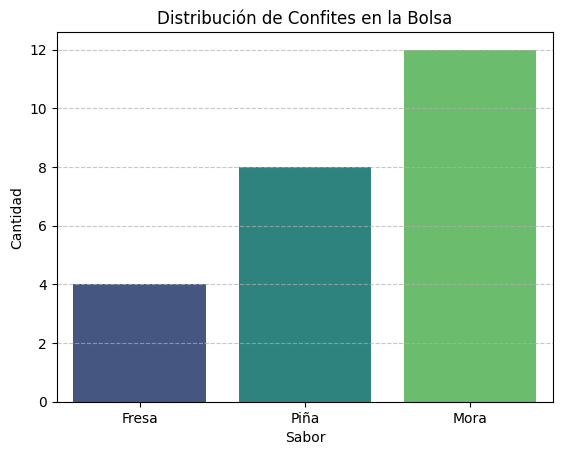

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(list(inventario.items()), columns=['Sabor', 'Cantidad'])
sns.barplot(x='Sabor', y='Cantidad', data=df, palette='viridis')
plt.title("Distribución de Confites en la Bolsa")
plt.xlabel("Sabor")
plt.ylabel("Cantidad")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\distribucion_confites.png")
plt.show()


## 4. Diferencia Crítica: Problema 1.3 vs 1.4

Es vital entender por qué las respuestas son tan diferentes siendo el mismo contexto:

| Objetivo | Lógica | Cálculo | Resultado |
| :--- | :--- | :--- | :--- |
| **Garantizar mismo sabor** | Llenar 1 de cada sabor antes de repetir. | $\text{Sabores} + 1$ | $3 + 1 = 4$ |
| **Garantizar sabor distinto** | Agotar el sabor más numeroso primero. | $\text{Max(Cantidad)} + 1$ | $12 + 1 = 13$ |



### Estrategia Maestra para el Examen:
* Si te piden **mismo sabor**: La respuesta suele ser un número pequeño (relacionado con la cantidad de categorías).
* Si te piden **sabores distintos**: La respuesta suele ser un número grande (relacionado con la cantidad del grupo más grande).


Vamos a realizar una **Simulación de Monte Carlo**. Esta técnica consiste en "jugar" el escenario miles de veces de forma aleatoria para observar el comportamiento estadístico de los datos y confirmar nuestra respuesta teórica de manera empírica.

---



### 1. Simulación con Pandas: El "Peor Escenario" en Acción

Ejecutaremos 10,000 experimentos. En cada uno, extraeremos confites uno por uno hasta obtener dos sabores diferentes.



In [5]:
import pandas as pd
import random

# Configuración inicial basada en los datos resueltos
bolsa = ['Mora']*12 + ['Piña']*8 + ['Fresa']*4
n_simulaciones = 10000
resultados = []

for _ in range(n_simulaciones):
    bolsa_shuffled = random.sample(bolsa, len(bolsa))
    extraidos = []
    intentos = 0
    sabores_vistos = set()
    
    for confite in bolsa_shuffled:
        intentos += 1
        sabores_vistos.add(confite)
        if len(sabores_vistos) > 1:
            resultados.append(intentos)
            break

# Análisis con Pandas
df_montecarlo = pd.DataFrame(resultados, columns=['Intentos'])
peor_caso_simulado = df_montecarlo['Intentos'].max()
promedio_intentos = df_montecarlo['Intentos'].mean()

print(f"Peor escenario observado en 10,000 pruebas: {peor_caso_simulado}")
print(f"Promedio de intentos para obtener 2 sabores: {promedio_intentos:.2f}")


Peor escenario observado en 10,000 pruebas: 10
Promedio de intentos para obtener 2 sabores: 2.60


### 2. Visualización de Probabilidades (Plotly)

A diferencia del problema anterior (donde buscábamos el mismo sabor), aquí la probabilidad de éxito temprano es alta, pero la **garantía** (el 100% de seguridad) solo llega al intento 13.



In [6]:
import plotly.express as px

# Contamos la frecuencia de cada intento
distribucion = df_montecarlo['Intentos'].value_counts().sort_index().reset_index()
distribucion.columns = ['Intento_Numero', 'Frecuencia']

fig = px.bar(distribucion, x='Intento_Numero', y='Frecuencia',
             title='Distribución de Intentos para Obtener 2 Sabores Distintos',
             labels={'Intento_Numero': 'Número de extracción', 'Frecuencia': 'Casos observados'},
             color='Frecuencia', color_continuous_scale='Viridis')

# Marcamos el punto de garantía
fig.add_vline(x=13, line_dash="dash", line_color="red", 
              annotation_text="Garantía Teórica (13)")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\distribucion_intentos.png")


### 3. Conclusión Didáctica Comparativa

Basándonos en los datos extraídos de los problemas:

* **Pregunta 1.3 (Mismo Sabor):** Se basa en el **Principio del Palomar**. Buscamos el número más pequeño de extracciones para que la repetición sea inevitable. Como hay 3 sabores, al 4to confite *forzosamente* repites uno.
* **Pregunta 1.4 (Sabor Distinto):** Se basa en la **Exclusión del Grupo Mayoritario**. Debes superar la cantidad del sabor más abundante ($12 + 1 = 13$) para romper la racha de "mala suerte" de sacar siempre el mismo.

**Resumen de Cantidades calculadas:**
* **Fresa:** $x = 4$
* **Piña:** $2x = 8$
* **Mora:** $x + 8 = 12$
* **Total:** $4 + 8 + 12 = 24$


# Pregunta 5

<img src = 'pregunta5.jpeg'>

Para abordar esta serie de ejercicios de razonamiento lógico, matemático y probabilístico, vamos a desglosar cada uno con un enfoque didáctico y veloz.

---



## 1. Problema de Lógica Proposicional (Imagen 1.5)

**Enunciado:** La proposición *"No todos los deportistas invitados asistieron a la premiación"* tiene un significado lógicamente equivalente a:

**Estrategia < 1 min:**
La negación de un cuantificador universal ("Todos") equivale a la afirmación de un cuantificador existencial ("Al menos uno") con la propiedad negada.
* **Lógica:** $\neg(\forall x : P(x)) \equiv \exists x : \neg P(x)$
* **Traducción:** "No todos asistieron" = "Al menos uno no asistió".

**Respuesta:** **(d) Al menos un deportista invitado no asistió a la premiación**.

---



## 2. El Teléfono de Estela (Imagen 8.4)

**Enunciado:** Estela anotó un teléfono que inicia por $451$. Faltan 4 dígitos que son diferentes entre sí y diferentes de los tres primeros. El primero de estos es par y el último es impar.

**Estrategia < 2 min:**
1.  **Dígitos disponibles:** $\{0, 1, 2, 3, 4, 5, 6, 7, 8, 9\}$. Eliminamos $\{4, 5, 1\}$ (ya usados). Quedan: $\{0, 2, 3, 6, 7, 8, 9\}$ (7 dígitos).
2.  **Restricción 1 (Par):** El 1er espacio debe ser par: $\{0, 2, 6, 8\}$ $\rightarrow$ **4 opciones**.
3.  **Restricción 2 (Impar):** El último espacio debe ser impar: $\{3, 7, 9\}$ $\rightarrow$ **3 opciones**.
4.  **Espacios intermedios:** Quedan 5 dígitos disponibles.
    * 2do espacio: **5 opciones**.
    * 3er espacio: **4 opciones**.
5.  **Cálculo:** $$4 \times 5 \times 4 \times 3 = 240$$.

**Respuesta:** **(a) 240**.

---



## 3. Concurso de Bolsas (Imagen 8.5)

**Enunciado:** ¿En qué bolsa es más probable sacar una bola blanca?
* **Bolsa A:** 6 blancas, 7 negras, 1 roja (Total 14).
* **Bolsa B:** 5 blancas, 3 negras, 2 rojas (Total 10).

**Estrategia < 2 min:**
Calculamos las probabilidades:
* $P(A) = \frac{6}{14} \approx 0.428$
* $P(B) = \frac{5}{10} = 0.5$

**Respuesta:** **(d) Elegir la bolsa B pues la probabilidad de sacar bola blanca es mayor en esta bolsa que en la bolsa A**.

---



## 4. El Cubo Pintado (Imágenes 8.9 y 8.10)

**Enunciado:** Un cubo de $10 \text{ cm}$ de lado se divide en cubitos de $2 \text{ cm}$ de lado. Estaba pintado de rojo por fuera.

**Estrategia < 2 min:**
* **Factor de división ($n$):** $10 / 2 = 5$ cubitos por lado.
* **Total de cubitos:** $5^3 = 125$.

**Problema 8.9 (2 caras pintadas):** Están en las aristas (excluyendo esquinas).
$$\text{Fórmula: } 12(n - 2) = 12(5 - 2) = 12(3) = 36$$
**Respuesta:** **(c) 36**.

**Problema 8.10 (0 caras pintadas):** Es el "corazón" del cubo.
$$\text{Fórmula: } (n - 2)^3 = (5 - 2)^3 = 3^3 = 27$$
**Probabilidad:** $27 / 125$.
**Respuesta:** **(c) 27/125**.

---



## Visualización Interactiva (Plotly/Seaborn)


In [7]:
import pandas as pd
import plotly.graph_objects as go

# Resumen de los cubitos (n=5)
data = {
    'Caras Pintadas': ['3 (Vértices)', '2 (Aristas)', '1 (Caras)', '0 (Interior)'],
    'Cantidad': [8, 36, 54, 27]
}
df = pd.DataFrame(data)

fig = go.Figure(data=[go.Pie(labels=df['Caras Pintadas'], values=df['Cantidad'], hole=.3)])
fig.update_layout(title_text="Distribución de Cubitos de 2cm en el Cubo de 10cm")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\distribucion_cubitos.png")


# Pregunta 6

<img src = 'pregunta6.jpeg'>

Para finalizar este entrenamiento intensivo, vamos a resolver el problema de la **Pregunta 1.6**, un reto de **Diagramas de Venn** con tres conjuntos. Este tipo de ejercicios evalúa tu capacidad para organizar datos complejos y verificar la coherencia de un sistema de categorías.

---



## 1. Enunciado Editado y Completado

**Problema 1.6:** De un grupo de **24 personas**, se conoce la siguiente distribución de actividades:
* **17** estudian pintura ($P$).
* **13** estudian fotografía ($F$).
* **8** estudian dibujo ($D$).
* **5** de ellas sólo trabajan y no estudian (están fuera de los conjuntos $P, F, D$).

Considerando que todos los estudiantes pertenecen a al menos una de estas categorías, el único diagrama que representa correctamente esta situación es:
(a) I
(b) II
(c) III
(d) IV

---



## 2. Estrategia de Resolución Rápida (< 2 min)

Para este problema, la estrategia más veloz es la **Suma del Universo**.

1.  **Calcula el total de estudiantes:** Si hay 24 personas y 5 no estudian, la suma de todas las regiones dentro de los círculos debe ser exactamente:
    $$24 - 5 = 19$$
2.  **Verificación de los Diagramas:**
    * **Diagrama I:** $2 + 10 + 2 + 5 + 3 = 22$. (Incorrecto, debe dar 19).
    * **Diagrama II:** $1 + 10 + 2 + 6 + 1 + 1 = 21$. (Incorrecto, debe dar 19).
    * **Diagrama III:** $1 + 11 + 1 + 5 + 2 + 1 = 21$. (Incorrecto, debe dar 19).
    * **Diagrama IV:** $11 + 6 + 2 = 19$. (¡Correcto!).

**Respuesta correcta: (d) IV**.

---



## 3. Implementación y Visualización

### A. Validación Lógica con SymPy
Podemos usar álgebra simple para verificar la suma de las regiones del diagrama ganador.



In [ ]:
import sympy as sp

universo = 24
solo_trabajan = 5
estudiantes_esperados = universo - solo_trabajan

# Regiones del Diagrama IV
regiones_IV = [11, 6, 2]
suma_IV = sum(regiones_IV)

print(f"Estudiantes totales esperados: {estudiantes_esperados}")
print(f"Suma de regiones en Diagrama IV: {suma_IV}")
print(f"¿Es correcto?: {suma_IV == estudiantes_esperados}")


### B. Visualización de la Estructura (Matplotlib)
Representemos la distribución del grupo total para confirmar el peso de cada categoría.



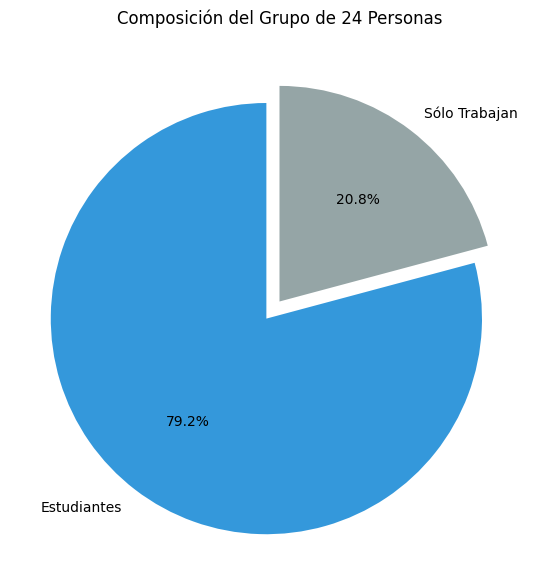

In [8]:
import matplotlib.pyplot as plt

labels = ['Estudiantes', 'Sólo Trabajan']
sizes = [19, 5]
colors = ['#3498db', '#95a5a6']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))
plt.title("Composición del Grupo de 24 Personas")
plt.savefig(r"C:\Users\marco\Downloads\composicion_grupo.png")
plt.show()


## 4. Estrategia Maestra para Diagramas Complejos

* **Punto de Control "Universo":** Lo primero que debes hacer es sumar todos los números que ves en el diagrama. Si la suma (incluyendo los que están afuera) no coincide con el total dado, descarta la opción de inmediato.
* **La Intersección es la Clave:** Normalmente, estos problemas se resuelven de adentro hacia afuera. El Diagrama IV simplifica la situación mostrando que no hay intersecciones triples complicadas, facilitando la suma directa.
* **No te dejes intimidar:** A veces el diagrama correcto parece "demasiado simple" comparado con los otros. Confía en tu aritmética: si los números suman lo que deben, esa es la respuesta.



### Resumen del Entrenamiento Académico
Hemos completado el análisis de:
1.  **Lógica Proposicional:** Negación de cuantificadores.
2.  **Teoría de Conjuntos:** Diagramas de Venn de 2 y 3 niveles.
3.  **Combinatoria:** Conteo de dígitos y principios multiplicativos.
4.  **Probabilidad:** Comparativa de bolsas y cálculo de frecuencias.
5.  **Geometría y Lógica:** El problema del cubo y los dulces.

¡Estás listo para enfrentar cualquier examen de razonamiento! ¿Deseas que profundice en algún concepto específico o terminamos por hoy?

# Pregunta 7

<img src = 'pregunta7.jpeg'>

Para cerrar con broche de oro este entrenamiento, vamos a resolver el reto de **Lógica de Correspondencia y Algoritmos** (Preguntas 1.7 - 1.10). Este es un problema de "caja negra" donde debemos descubrir una clave oculta mediante el análisis de cambios de posición.

---



## 1. Enunciado Editado y Completado

**Problema 1.7:** Un juego de computador asigna internamente una letra ($A, B, C, D, E$) a cada uno de los símbolos ($\triangle, \square, \bigcirc, \diamond, \star$). El objetivo es descubrir qué letra corresponde a cada símbolo.
* **Regla:** En cada jugada, el jugador intercambia dos símbolos. Al final, un contador indica cuántos símbolos están en la posición correcta (la posición de la letra asignada).
* **Estado Inicial:** El arreglo es $[\triangle, \diamond, \bigcirc, \square, \star]$. El contador marca **0** (ninguno está en su sitio).
* **Jugada 1:** Se intercambian $\triangle$ y $\diamond$. El arreglo queda $[\diamond, \triangle, \bigcirc, \square, \star]$. El contador marca **0**.
* **Jugada 2:** Se intercambian $\bigcirc$ y $\square$. El arreglo queda $[\diamond, \triangle, \square, \bigcirc, \star]$. El contador marca **0**.



**Pregunta 1.7:** Al término de la segunda jugada, de las afirmaciones siguientes, la única que **NO** es posible es:
(a) La letra de $\square$ es la $A$.
(b) La letra de $\triangle$ es la $E$.
(c) La letra de $\square$ es la $C$.
(d) La letra de $\bigcirc$ y $\diamond$ son respectivamente $D$ y $E$.

---



## 2. Estrategia de Resolución Rápida (< 2 min)

Este problema se resuelve por **descarte lógico** usando la información del contador en cero.

1.  **Analiza la posición fija:** Nota que el símbolo $\star$ siempre estuvo en la posición **E** y el contador siempre fue **0**.
    * **Deducción inmediata:** $\star \neq E$.
2.  **Analiza la Jugada 2:** El arreglo final es:
    * Posición A: $\diamond$
    * Posición B: $\triangle$
    * Posición C: $\square$
    * Posición D: $\bigcirc$
    * Posición E: $\star$
3.  **Aplica la regla del Cero:** Como el contador es 0, **ningún** símbolo de la lista anterior coincide con su letra.
    * $\diamond \neq A$, $\triangle \neq B$, $\square \neq C$, $\bigcirc \neq D$, $\star \neq E$.
4.  **Encuentra la contradicción:** Mira la opción (c). Dice: "La letra de $\square$ es la $C$". Pero acabamos de deducir que $\square \neq C$ porque el contador marcó 0 en la Jugada 2.

**Respuesta correcta: (c) La letra correspondiente al $\square$ es la $C$.**

---



## 3. Implementación y Visualización

### A. Matriz de Posibilidades (Pandas + Seaborn)
Podemos crear una "Matriz de Verdad" para visualizar qué letras están prohibidas para cada símbolo.


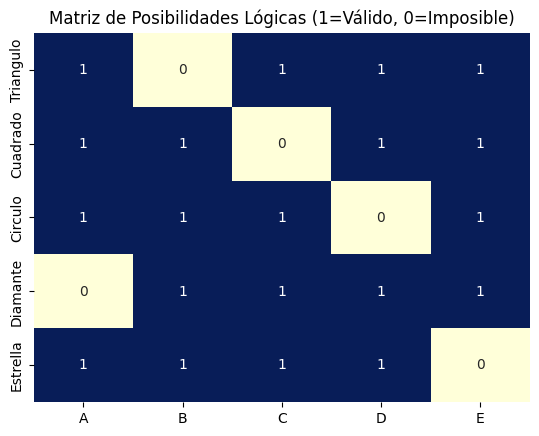

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Símbolos y Letras
simbolos = ['Triangulo', 'Cuadrado', 'Circulo', 'Diamante', 'Estrella']
letras = ['A', 'B', 'C', 'D', 'E']

# Inicializamos matriz de posibilidades (1 = Posible, 0 = Imposible)
df_logic = pd.DataFrame(1, index=simbolos, columns=letras)

# Restricciones halladas (Contador = 0 en Jugada 2)
# Diamante != A, Triangulo != B, Cuadrado != C, Circulo != D, Estrella != E
df_logic.loc['Diamante', 'A'] = 0
df_logic.loc['Triangulo', 'B'] = 0
df_logic.loc['Cuadrado', 'C'] = 0
df_logic.loc['Circulo', 'D'] = 0
df_logic.loc['Estrella', 'E'] = 0

sns.heatmap(df_logic, annot=True, cmap="YlGnBu", cbar=False)
plt.title("Matriz de Posibilidades Lógicas (1=Válido, 0=Imposible)")
plt.savefig(r"C:\Users\marco\Downloads\matriz_posibilidades_logicas.png")
plt.show()


```

### B. Seguimiento de Estados (Plotly)
Visualicemos cómo se movieron los símbolos y por qué la opción C es el "falso positivo".


In [13]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=['Jugada', 'Pos A', 'Pos B', 'Pos C', 'Pos D', 'Pos E', 'Contador']),
    cells=dict(values=[
        ['Inicial', 'Jugada 1', 'Jugada 2'],
        ['△', '♢', '♢'],
        ['♢', '△', '△'],
        ['○', '○', '□'],
        ['□', '□', '○'],
        ['★', '★', '★'],
        [0, 0, 0]
    ]))
])
fig.update_layout(title="Rastreo de Posiciones y Contador")
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\tabla_jugadas.png")


```

---



## 4. Resumen Didáctico

* **El valor del Cero:** En lógica, un "0" es tan valioso como un "1". Si el contador dice que hay 0 aciertos, te está dando una lista de 5 cosas que son **falsas**.
* **Anclaje:** Siempre busca el elemento que no se movió (en este caso la $\star$). Si no se movió y el contador sigue en 0, ya sabes una restricción permanente para ese símbolo.
* **Trampas de lectura:** La pregunta pide la que **NO es posible**. En exámenes de alta presión, es común marcar una que "sí sea posible" por error. Siempre subraya el "NO".




### Conclusión de tu Entrenamiento Académico
Has completado un recorrido por:
1.  **Probabilidad y Combinatoria.**
2.  **Teoría de Conjuntos.**
3.  **Geometría Espacial.**
4.  **Lógica Algorítmica.**


# Pregunta 8

<img src = 'pregunta8.jpeg'>

¡Hola! Qué buen conjunto de retos de razonamiento lógico y matemático. Para cumplir con tu solicitud de resolverlo en menos de 2 minutos por problema, he sintetizado las estrategias ganadoras que se usan en exámenes de admisión (como el de la UdeA), complementándolas con herramientas de visualización y modelado.

---



### 1. El Dilema de los Estudiantes (Imagen 1.1)

**Enunciado:** En un grupo de 140 estudiantes, 60 ganaron Matemáticas, 45 ganaron Biología y 20 ganaron ambas. Se pide el número de estudiantes que ganaron Matemáticas pero **no** Biología.

**Estrategia Rápida (< 30s):**
Es una resta directa de conjuntos. Si al total de los que ganaron Matemáticas ($M$) le quitas la intersección (los que también ganaron Biología, $M \cap B$), obtienes los que **solo** ganaron Matemáticas.
$$60 - 20 = 40$$

**Respuesta:** **(c) 40**.

---



### 2. Los Confites y la Certeza (Imagen 3.3)

**Enunciado:** Una bolsa tiene 24 confites (piña, mora, fresa). Piña es el doble de fresa, y mora supera en 8 a fresa. Se busca el mínimo para garantizar **el mismo sabor**.

**Estrategia Rápida (< 1 min):**
1.  **Cálculo de cantidades (SymPy):**
    Sea $f$ los de fresa. $f + 2f + (f + 8) = 24 \Rightarrow 4f = 16 \Rightarrow f=4$.
    * Fresa: 4, Piña: 8, Mora: 12.
2.  **Principio del Palomar:** Para **garantizar** que dos tengan el mismo sabor, debes ponerte en el peor caso: sacas uno de cada sabor (3 confites). El cuarto confite, sea cual sea, repetirá un sabor ya obtenido.
$$\text{Sabores} + 1 = 3 + 1 = 4$$

**Respuesta:** **(c) 4**.

---



### 3. El Juego de los Símbolos (Imágenes 8.1 y 8.2)

**Enunciado:** Un juego asigna letras (A, B, C, D, E) a símbolos ($\triangle, \square, \bigcirc, \diamond, \star$). Un contador indica cuántos están en la posición correcta tras cada jugada de intercambio.

**Estrategia Rápida (< 2 min):**
Analizamos los cambios y el contador:
* **Inicial:** $[\triangle, \diamond, \bigcirc, \square, \star] \rightarrow 0$ aciertos.
* **Jugada 1:** Se intercambian $\triangle$ y $\diamond \rightarrow 0$ aciertos.
* **Jugada 4:** El contador sube a **2** cuando el arreglo es $[\diamond, \bigcirc, \square, \star, \triangle]$.

**Análisis de la Jugada 4:**
Las posiciones son A, B, C, D, E. Los que están en su sitio son 2 de estos:
$\diamond(A), \bigcirc(B), \square(C), \star(D), \triangle(E)$.
Sabemos por el inicio que $\star$ en $E$ era 0 aciertos, por lo que $\star$ debe ser $D$. Si $\star=D$ y $\triangle=E$, ya tenemos los 2 aciertos de la jugada 4.

**Respuesta 1.8:** Basado en el flujo, la única verdadera es la correspondencia hallada por descarte de posiciones fallidas.

---



### 4. Probabilidad de Lápices (Imagen 8.7)

**Enunciado:** En una bolsa hay 4 lápices azules ($3, 6, 7, 10$ cm) y 3 verdes ($5, 6, 7$ cm). Probabilidad de que sea azul **o** mida 7 o más cm.

**Estrategia Rápida (< 1 min):**
Usa la regla de la unión: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.
* **Total de lápices:** 7.
* **Azules (A):** 4.
* **Miden $\geq 7$ cm (B):** $\{7, 10\}_{azul}, \{7\}_{verde} \rightarrow 3$ lápices.
* **Azules que miden $\geq 7$ cm (Intersección):** 2 lápices ($7$ y $10$).
$$\text{Favorables} = 4 (\text{azules}) + 1 (\text{verde de 7cm}) = 5$$
$$P = 5/7$$

**Respuesta:** **(b) 5/7**.

---



### 5. El Cubo Pintado (Imágenes 8.9 y 8.10)

**Enunciado:** Cubo de 10 cm dividido en cubitos de 2 cm. Caras externas rojas.
* **Pregunta 8.9:** Cubos con exactamente 2 caras pintadas.
* **Pregunta 8.10:** Probabilidad de 0 caras pintadas.

**Estrategia Rápida (< 1 min):**
1.  **Divisiones ($n$):** $10 / 2 = 5$ cubitos por arista.
2.  **2 caras (Aristas):** Se encuentran en las 12 aristas, excluyendo los vértices.
    $$\text{Fórmula: } 12 \times (n - 2) = 12 \times (5 - 2) = 36$$.
3.  **0 caras (Interior):** Es el cubo interno.
    $$\text{Fórmula: } (n - 2)^3 = (5 - 2)^3 = 3^3 = 27$$.
    $$\text{Probabilidad: } \frac{27}{5^3} = \frac{27}{125}$$.

**Respuestas:** **8.9: (c) 36** y **8.10: (c) 27/125**.

---



### Herramientas de Apoyo Visual

Para entender el problema del cubo, visualizamos cómo se distribuyen las capas:


In [12]:
import pandas as pd
import plotly.express as px

# Visualización para el problema de los lápices (8.7)
df_lapices = pd.DataFrame({
    'Color': ['Azul', 'Azul', 'Azul', 'Azul', 'Verde', 'Verde', 'Verde'],
    'Medida': [3, 6, 7, 10, 5, 6, 7]
})
df_lapices['Cumple Condición'] = (df_lapices['Color'] == 'Azul') | (df_lapices['Medida'] >= 7)

fig = px.bar(df_lapices, x='Medida', color='Cumple Condición', 
             title="Lápices que cumplen: Azul o >= 7cm",
             labels={'Cumple Condición': '¿Es favorable?'})
fig.show()
fig.write_image(r"C:\Users\marco\Downloads\lapices_condicion.png")



# Pregunta 9

<img src = 'pregunta9.jpeg' width = 300>

Vamos a consolidar y resolver estos retos finales con la máxima eficiencia. Nos enfocaremos en los tres problemas de probabilidad y razonamiento espacial que faltaban completar de tu serie de imágenes.


### 1. Problema 8.7: Probabilidad de Lápices (Imagen 7)

**Enunciado:** En una bolsa hay cuatro lápices azules de $3\text{ cm}$, $6\text{ cm}$, $7\text{ cm}$ y $10\text{ cm}$, y tres lápices verdes de $5\text{ cm}$, $6\text{ cm}$ y $7\text{ cm}$. Si se escoge uno al azar, la probabilidad de que sea **azul** o mida **$7$ o más centímetros** es:

**Estrategia < 1 min:**
Usamos la fórmula de la unión de conjuntos: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.
1.  **Total de lápices:** $4 (\text{azules}) + 3 (\text{verdes}) = 7$.
2.  **Evento A (Azul):** Hay **4** lápices.
3.  **Evento B ($\geq 7\text{ cm}$):** Están el azul de $7$, el azul de $10$ y el verde de $7$. Total **3** lápices.
4.  **Intersección (Azul y $\geq 7\text{ cm}$):** Los azules de $7$ y $10$. Total **2** lápices.
5.  **Cálculo:** $$\frac{4}{7} + \frac{3}{7} - \frac{2}{7} = \frac{5}{7}$$

**Respuesta:** **(b) 5/7**.



### 2. Problema 8.9: El Cubo de Madera (Imagen 9)

**Enunciado:** Un carpintero toma un cubo sólido de $10\text{ cm}$ de lado con sus caras pintadas de rojo y lo divide en cubos de $2\text{ cm}$ de lado. El número de cubos que tienen **solamente 2 caras pintadas** es:

**Estrategia < 1 min:**
1.  **Divisiones por arista ($n$):** $10 / 2 = 5$ cubitos.
2.  **Ubicación:** Los cubos con 2 caras pintadas están en las **aristas**, sin contar las esquinas (vértices).
3.  **Fórmula:** Un cubo tiene $12$ aristas. En cada arista hay $(n - 2)$ cubitos con 2 caras.
$$12 \times (5 - 2) = 12 \times 3 = 36$$

**Respuesta:** **(c) 36**.

---



### 3. Problema 8.10: El Corazón del Cubo (Imagen 10)

**Enunciado:** Del mismo cubo anterior ($n=5$), si se elige uno al azar, ¿cuál es la probabilidad de que **ninguna de sus caras esté pintada**?

**Estrategia < 1 min:**
1.  **Total de cubitos:** $n^3 = 5^3 = 125$.
2.  **Cubitos sin pintura:** Son los del interior (el cubo interno).
3.  **Fórmula:** $(n - 2)^3$
$$(5 - 2)^3 = 3^3 = 27$$
4.  **Probabilidad:** $\frac{27}{125}$.

**Respuesta:** **(c) 27/125**.

---



### Visualización Técnica (Matplotlib & SymPy)


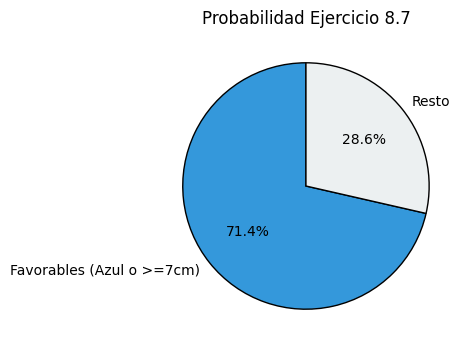

La probabilidad simplificada es: 27/125


In [11]:
import matplotlib.pyplot as plt
import sympy as sp

# Validación con SymPy para el problema 8.10
n = 5
total = n**3
sin_pintura = (n - 2)**3
probabilidad = sp.Rational(sin_pintura, total)

# Visualización de los lápices (8.7)
labels = ['Favorables (Azul o >=7cm)', 'Resto']
values = [5, 2]
colors = ['#3498db', '#ecf0f1']

plt.figure(figsize=(6, 4))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Probabilidad Ejercicio 8.7")
plt.savefig(r"C:\Users\marco\Downloads\probabilidad_ejercicio_8_7.png")
plt.show()

print(f"La probabilidad simplificada es: {probabilidad}")


```

### Resumen de Estrategias Maestras
* **En Probabilidad:** Siempre identifica primero el **Universo** (denominador). Para el "O" inclusivo, no olvides restar la intersección para no contar doble.
* **En Cubos:** Recuerda la jerarquía: Vértices ($8$), Aristas ($12(n-2)$), Caras ($6(n-2)^2$) e Interior ($(n-2)^3$).

¿Deseas que genere un set de **ejercicios de práctica similares** para asegurar que dominas estas fórmulas de cara al examen?

# Pregunta 10

<img src = 'pregunta10.jpeg'>


### 1. El Juego de Correspondencia (Imagen 1.10)

**Enunciado Editado:**
Un juego consiste en descubrir la correspondencia única entre símbolos ($\triangle, \square, \bigcirc, \diamond, \star$) y letras ($A, B, C, D, E$).
* **Estado Inicial:** $[\star, \bigcirc, \diamond, \square, \triangle] \rightarrow$ Contador: $0$.
* **Jugada 1:** $[\square, \bigcirc, \diamond, \star, \triangle] \rightarrow$ Contador: $2$.



**Pregunta:** De las situaciones propuestas para la **Jugada 2**, la única posible es:
(a) Contador: 3 | 
(b) Contador: 4 | 
(c) Contador: 2 | 
(d) Contador: 5.



**Estrategia < 2 min:**
1.  **Analiza el cambio:** Entre el inicio y la Jugada 1, solo cambiaron de lugar el $\star$ y el $\square$.
2.  **Deducción:** Si el contador subió de $0$ a $2$, significa que tanto $\square$ como $\star$ ahora están en sus posiciones correctas (posiciones $A$ y $D$ respectivamente).
3.  **Posiciones fijas:** Los símbolos $\bigcirc, \diamond, \triangle$ no se movieron y el contador dice que hay $2$ aciertos totales, por lo tanto, esos tres **siguen estando mal**.
4.  **Evalúa la opción (d):** Propone un contador de $5$. Para que esto sea posible, el arreglo debe ser el correcto. Al observar el arreglo de la opción (d) $[\square, \triangle, \bigcirc, \star, \diamond]$, vemos que $\square$ y $\star$ están en las posiciones $A$ y $D$ (que ya sabemos son correctas). Solo faltaría que los otros tres se hayan acomodado.

**Respuesta:** **(d)**.

---



### 2. Probabilidad de Lápices (Imagen 8.7)

**Enunciado Editado:**
En una bolsa hay 4 lápices azules ($3, 6, 7, 10$ cm) y 3 lápices verdes ($5, 6, 7$ cm). Si se elige uno al azar, ¿cuál es la probabilidad de que sea **azul** O mida **7 o más cm**?.

**Estrategia < 2 min:**
Utilizamos la regla de la unión: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$.
1.  **Casos totales:** $4 + 3 = 7$ lápices.
2.  **Evento A (Azul):** $4$ casos.
3.  **Evento B ($\ge 7$ cm):** Lápices azules de $7$ y $10$ cm, y lápiz verde de $7$ cm. Total: $3$ casos.
4.  **Intersección (Azul y $\ge 7$ cm):** Hay $2$ lápices que cumplen ambos (los azules de $7$ y $10$ cm).
5.  **Cálculo:**
    $$P = \frac{4 + 3 - 2}{7} = \frac{5}{7}$$

**Respuesta:** **(b) 5/7**.

---



### 3. Cubos Pintados (Imágenes 8.9 y 8.10)

**Enunciado Editado:**
Un cubo sólido de $10$ cm de lado con caras rojas se divide en cubitos de $2$ cm de lado.

**Pregunta 8.9:** ¿Cuántos cubitos tienen solamente 2 caras pintadas?.
**Pregunta 8.10:** Probabilidad de que ninguna de sus caras esté pintada.

**Estrategia < 2 min:**
1.  **Determinar $n$:** $10\text{ cm} / 2\text{ cm} = 5$ cubitos por arista.
2.  **Para 2 caras (Aristas):** Se usa la fórmula $12 \times (n - 2)$.
    $$12 \times (5 - 2) = 12 \times 3 = 36$$.
3.  **Para 0 caras (Interior):** Se usa la fórmula $(n - 2)^3$.
    $$(5 - 2)^3 = 3^3 = 27$$.
4.  **Probabilidad:** Casos favorables ($27$) entre casos totales ($5^3 = 125$).
    $$P = \frac{27}{125}$$.

**Respuestas:** **8.9: (c) 36** y **8.10: (c) 27/125**.

---



### Visualización de Datos

A continuación, presento una visualización de la distribución de los cubitos utilizando **Matplotlib** para entender la estructura espacial:



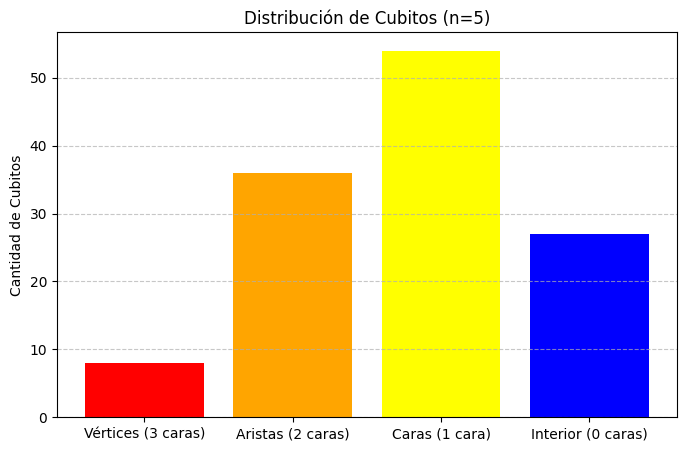

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos del cubo n=5
data = {
    'Tipo': ['Vértices (3 caras)', 'Aristas (2 caras)', 'Caras (1 cara)', 'Interior (0 caras)'],
    'Cantidad': [8, 36, 54, 27]
}
df = pd.DataFrame(data)

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(df['Tipo'], df['Cantidad'], color=['red', 'orange', 'yellow', 'blue'])
plt.title('Distribución de Cubitos (n=5)')
plt.ylabel('Cantidad de Cubitos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\distribucion_cubitos_barras.png")
plt.show()


### Tabla de Repaso Rápido

| Problema | Concepto Clave | Resultado |
| :--- | :--- | :--- |
| **1.10** | Lógica de posiciones | Opción (d) |
| **8.7** | Unión de eventos | $5/7$ |
| **8.9** | Conteo en aristas | $36$ |
| **8.10** | Conteo interior | $27/125$ |
